# 07. Approval thresholds and the final test

**Objective.** Turn probabilities into approve/decline decisions, show how the decision depends on business assumptions, and report final performance on the untouched test split.

**Business question.** If the lender approves every applicant whose predicted default probability is below a cutoff, what happens to approval volume, default rate and value at different cutoffs?

**Why this analysis is needed.** A model outputs a probability, not a decision. The cutoff is a business choice, and it must be shown together with the assumptions that produce it.

*Educational project. Not a lending policy. The loss and margin figures below are project-defined illustrations, not Home Credit's numbers, and the TARGET is early repayment difficulty, not lifetime default.*

## Assumptions (project-defined, changeable)

| Assumption | Value | Meaning |
|---|---|---|
| Exposure at default (EAD) | `AMT_CREDIT` | Full loan amount is at risk; no repayments before default |
| Loss given default (LGD) | 45% | Share of the exposure lost if the applicant defaults |
| Margin on a good loan | 8% of `AMT_CREDIT` | Net profit from a loan that is repaid |

Net value of a threshold = margin on approved non-defaulters minus LGD times exposure on approved defaulters. Declined applicants contribute zero. These are round numbers chosen for illustration; the sensitivity table below shows how much the answer depends on them.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_auc_score
from src.data import load_modelling_table
from src.plots import apply_style
from src.policy import approval_table, best_threshold
from src.train import *

warnings.filterwarnings("ignore")
apply_style()
table = load_modelling_table()
columns = feature_columns(table, ratios=True, history=True, drop=SOCIAL_CIRCLE)
valid = table[table["split"] == "valid"]
model = make_boosting(table, columns, max_depth=4, learning_rate=0.05)
_, valid_pd = fit_and_score(model, table, columns)
thresholds = np.round(np.arange(0.04, 0.40, 0.02), 2)
policy = approval_table(valid[config.TARGET], valid_pd, valid["AMT_CREDIT"], thresholds)
best = best_threshold(policy)
show = policy.copy()
show["net_value_m"] = show["net_value"] / 1e6
print(show.drop(columns="net_value").round(4).to_string(index=False))
print("approve everyone: net value (millions) =", round(approval_table(valid[config.TARGET], valid_pd, valid["AMT_CREDIT"], [1.0])["net_value"][0] / 1e6, 1))
print("best threshold on validation:", best["threshold"])

 threshold  approval_rate  default_rate_approved  defaulters_declined_share  net_value_m
      0.04         0.4070                 0.0215                     0.8916    1098.3676
      0.06         0.5685                 0.0297                     0.7911    1411.2827
      0.08         0.6755                 0.0360                     0.6987    1575.0061
      0.10         0.7462                 0.0416                     0.6153    1643.7806
      0.12         0.7987                 0.0468                     0.5368    1674.7198
      0.14         0.8378                 0.0508                     0.4725    1689.4045
      0.16         0.8682                 0.0543                     0.4155    1691.7559
      0.18         0.8924                 0.0575                     0.3639    1686.8166
      0.20         0.9114                 0.0603                     0.3190    1669.7367
      0.22         0.9269                 0.0629                     0.2777    1651.3181
      0.24         0.

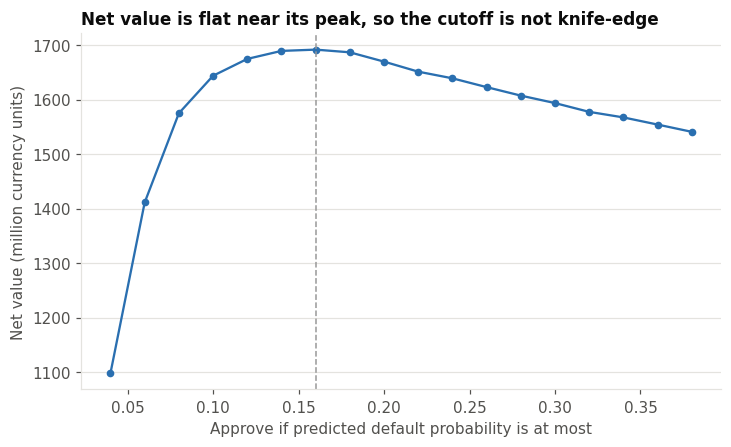

In [2]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(policy["threshold"], policy["net_value"] / 1e6, color="#2a6fb0", marker="o", markersize=4)
ax.axvline(best["threshold"], color="#999999", linestyle="--", linewidth=1)
ax.set_xlabel("Approve if predicted default probability is at most")
ax.set_ylabel("Net value (million currency units)")
ax.set_title("Net value is flat near its peak, so the cutoff is not knife-edge", loc="left")
plt.show()

**Result.** On validation, net value is highest at a cutoff of 0.16 (1,692 million currency units): 86.8% of applicants approved, 5.4% default rate among the approved (against 8.1% overall), and 41.6% of defaulters declined. Approving everyone gives 1,464 million, so the cutoff adds 228 million (about 16%). Between 0.12 and 0.20 the value stays within 1.3% of the peak.

**Interpretation.** Declining the riskiest ~13% of applicants removes about 42% of the defaulters. The curve is flat near the top: cutoffs from 0.12 to 0.20 give almost the same value, but very different approval rates (80% to 91%). That gap is where a lender's other goals (growth, risk appetite) belong; the model cannot choose it.

## How much do the assumptions matter?

The best cutoff is recomputed for a grid of LGD and margin values.

In [3]:
rows = []
for lgd in [0.30, 0.45, 0.60]:
    for margin in [0.04, 0.08, 0.12]:
        result = best_threshold(approval_table(valid[config.TARGET], valid_pd, valid["AMT_CREDIT"], thresholds, lgd=lgd, margin=margin))
        rows.append({"LGD": lgd, "margin": margin, "best_threshold": result["threshold"], "approval_rate": result["approval_rate"], "default_rate_approved": result["default_rate_approved"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 LGD  margin  best_threshold  approval_rate  default_rate_approved
0.30    0.04            0.10          0.746                  0.042
0.30    0.08            0.20          0.911                  0.060
0.30    0.12            0.30          0.966                  0.070
0.45    0.04            0.08          0.675                  0.036
0.45    0.08            0.16          0.868                  0.054
0.45    0.12            0.20          0.911                  0.060
0.60    0.04            0.06          0.568                  0.030
0.60    0.08            0.10          0.746                  0.042
0.60    0.12            0.18          0.892                  0.058


**Result.** The best cutoff moves from 0.06 (LGD 60%, margin 4%) to 0.30 (LGD 30%, margin 12%), and the approval rate from 57% to 97%.

**Interpretation.** The cutoff is not a property of the model: it is a property of the assumptions about loss and margin. The same model supports very different policies. Any threshold quoted from this project must be quoted together with its LGD and margin.

**Decision.** Use 0.16 as the illustrative cutoff under the stated assumptions (LGD 45%, margin 8%), fixed before the test split is opened. See D28.

## The final test

The test split is opened here, once. The chosen model (boosting, depth 4, learning rate 0.05, no class weights, no calibrator) and the logistic benchmark are refitted on the training split only and scored on the test split. The cutoff was fixed on validation before this step. Nothing is changed after seeing these numbers.

In [4]:
test = table[table["split"] == "test"]
test_scores, test_pd = final_test_score(make_boosting(table, columns, max_depth=4, learning_rate=0.05), table, columns)
benchmark_scores, benchmark_pd = final_test_score(make_logistic(table, columns, log_amounts=True), table, columns)
print(pd.DataFrame({"boosting": test_scores, "logistic": benchmark_scores}).T.round(4).to_string())

y_test = test[config.TARGET].to_numpy()
rng = np.random.default_rng(config.RANDOM_SEED)
draws = []
for _ in range(300):
    rows = rng.integers(0, len(y_test), len(y_test))
    draws.append((roc_auc_score(y_test[rows], test_pd[rows]), roc_auc_score(y_test[rows], test_pd[rows]) - roc_auc_score(y_test[rows], benchmark_pd[rows])))
draws = np.array(draws)
print("boosting AUC 95% interval:", np.round(np.percentile(draws[:, 0], [2.5, 97.5]), 4))
print("boosting minus logistic AUC, mean and 95% interval:", round(draws[:, 1].mean(), 4), np.round(np.percentile(draws[:, 1], [2.5, 97.5]), 4))

at_cutoff = approval_table(y_test, test_pd, test["AMT_CREDIT"], [best["threshold"]])
approve_all = approval_table(y_test, test_pd, test["AMT_CREDIT"], [1.0])
print(pd.concat([at_cutoff, approve_all]).round(4).to_string(index=False))

          roc_auc  pr_auc      ks   brier  mean_predicted  actual_rate
boosting   0.7749  0.2700  0.4147  0.0665          0.0805       0.0807
logistic   0.7630  0.2523  0.3945  0.0674          0.0804       0.0807
boosting AUC 95% interval: [0.7675 0.7816]
boosting minus logistic AUC, mean and 95% interval: 0.0121 [0.0091 0.015 ]
 threshold  approval_rate  default_rate_approved  defaulters_declined_share    net_value
      0.16         0.8717                 0.0534                     0.4238 1.719016e+09
      1.00         1.0000                 0.0807                     0.0000 1.470267e+09


**Result.** On the test split the boosting model gets ROC-AUC 0.7749 (95% interval 0.7675 to 0.7816), PR-AUC 0.2700 (random: 0.0807), KS 0.415 and Brier 0.0665 (constant-rate: 0.0742). The logistic benchmark gets 0.7630, so boosting is ahead by 0.0121 (0.0091 to 0.0150). Mean predicted probability is 8.05% against 8.07% actual. At the 0.16 cutoff, 87.2% of test applicants are approved, the default rate among them is 5.3%, 42.4% of defaulters are declined, and net value is 1,719 million against 1,470 million for approving everyone (+16.9%).

**Interpretation.** The test AUC is higher than validation (0.7705), by 0.004, which is about one bootstrap standard error. There is no sign of overfitting to validation; the gap is sampling noise and the direction is favourable, so no claim should be made that the model is better on new data than on validation. The boosting-over-logistic gap replicates (0.012 on test, 0.011 on validation).

**Limits.** These numbers come from one random split of one historical portfolio with no time dimension, so they say nothing about performance after economic change. The value figures depend entirely on the illustrative LGD and margin.

In [5]:
import json
from src import config
config.MODELS_DIR.mkdir(exist_ok=True)
config.REPORTS_DIR.mkdir(exist_ok=True)
final = make_boosting(table, columns, max_depth=4, learning_rate=0.05)
final.fit(table[table["split"] == "train"][columns], table[table["split"] == "train"][config.TARGET])
joblib.dump({"model": final, "columns": columns, "threshold": float(best["threshold"])}, config.MODELS_DIR / "pd_model.joblib")
metrics = {"test": {k: float(v) for k, v in test_scores.items()}, "benchmark_test": {k: float(v) for k, v in benchmark_scores.items()}, "threshold": float(best["threshold"]), "assumptions": {"lgd": 0.45, "margin": 0.08}}
(config.REPORTS_DIR / "metrics.json").write_text(json.dumps(metrics, indent=1))
print("saved model with", len(columns), "columns")

saved model with 142 columns


## Next step

Phase 8: where does the model fail (by segment, age and gender group), which inputs drive individual predictions, risk bands, and expected loss per applicant.